# SciPy Bootcamp — W2, Day D4
```
##### Multi-group comparison, post-hoc, interaction, ANCOVA
##### f_oneway, Tukey HSD, OLS with C(), interaction terms
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — One-way ANOVA with visualization first
##### Q2 — Post-hoc testing with visualization
##### Q3 — Two-way ANOVA with interaction
##### Q4 — ANCOVA — controlling for user tenure

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — One-way ANOVA with visualization first

```
# Simulate session duration for 4 MedPulse traffic sources:
# Organic: Normal(4.2, 1.1, 80), Direct: Normal(5.1, 1.3, 60)
# Social:  Normal(2.8, 0.9, 70), Email:  Normal(6.3, 1.4, 50)
# (a) FIRST: plot box plots and violin plots side by side (2-panel).
#     What do you notice BEFORE running any test?
# (b) Check assumptions: Shapiro-Wilk per group, Levene's test.
#     Print results and flag any violations.
# (c) Run one-way ANOVA. Print F-statistic and p-value.
# (d) The chart should make the conclusion obvious — does it?
```


In [25]:
# (a) FIRST: plot box plots and violin plots side by side (2-panel).
#     What do you notice BEFORE running any test?

np.random.seed(420)

organic = np.random.normal(loc=4.2, scale=1.1, size=80)
direct  = np.random.normal(loc=5.1, scale=1.3, size=60)
social  = np.random.normal(loc=2.8, scale=0.9, size=70)
email   = np.random.normal(loc=6.3, scale=1.4, size=50)

data    = np.concatenate([organic, direct, social, email])
groups   = ['organic']*80 + ['direct']*60 + ['social']*70 + ['email']*50

df = pd.DataFrame({
    'time_on_page': data,
    'traffic_source': groups
})

print(df.head())

   time_on_page traffic_source
0      3.666070        organic
1      2.104331        organic
2      3.621156        organic
3      3.855099        organic
4      4.563777        organic


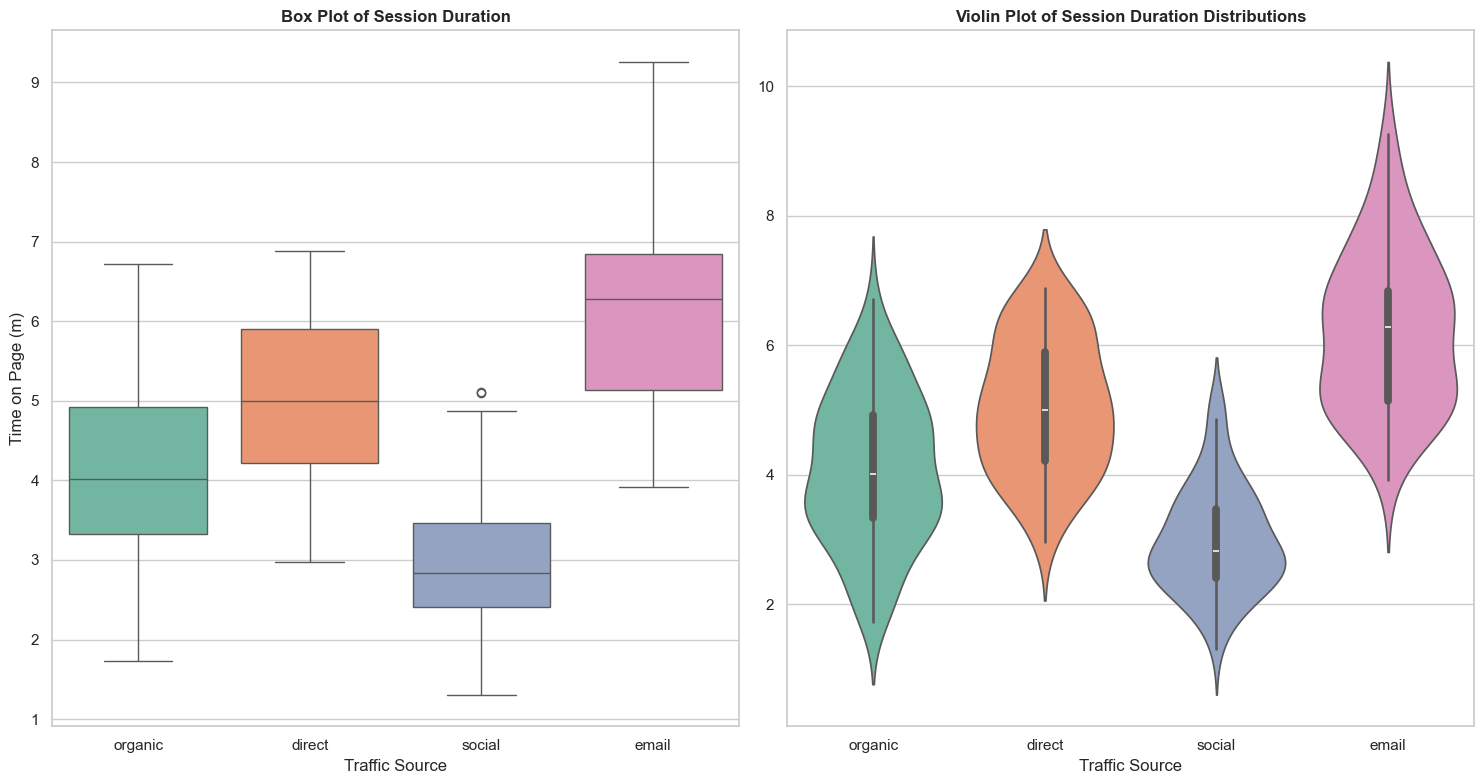

In [26]:
plt.figure(figsize=(15,8))

# Panel 1: Box Plots
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='traffic_source', y='time_on_page', palette='Set2')
plt.title('Box Plot of Session Duration', fontweight='bold', fontsize=12)
plt.xlabel('Traffic Source')
plt.ylabel('Time on Page (m)')


# Panel 2: Violin Plots (Side-by-side)
plt.subplot(1, 2, 2)
sns.violinplot(data=df, x='traffic_source', y='time_on_page', palette='Set2')
plt.title('Violin Plot of Session Duration Distributions', fontweight='bold', fontsize=12)
plt.xlabel('Traffic Source')
plt.ylabel('')  # Clear redundant y-axis label


plt.tight_layout()
plt.show()

In [27]:
# (b) Check assumptions: Shapiro-Wilk per group, Levene's test.
#     Print results and flag any violations.

# noramlitty of data using stats.shapiro()
for g in df['traffic_source'].unique():
    stat, p_shapiro = stats.shapiro(df[df['traffic_source']==g]['time_on_page'])
    print(f"Shapiro-Wilk's p-value of {g}: {p_shapiro:.4f}") # p > 0.05 → equal variances
    if p_shapiro > 0.05:
        print('VERDICT: Distribution is normal')
    else:
        print('WARNING: Distribution is NOT normal')

# homogeneity of variance using stats.levene()
stat, p = stats.levene(organic, social, email, direct)
print(f"Levene's p-value: {p:.4f}") # p > 0.05 → equal variances
if p > 0.05:
    print('VERDICT: Variances among groups are equal (Homoscedasticity holds)')
else:
    print('WARNING: Variances among groups are NOT equal (Heteroscedasticity detected)')

# Levene fails so equal variance assumption is violated. 
# However with these sample sizes (n=50–80), ANOVA is reasonably robust. 
# Consider Welch's ANOVA as an alternative


Shapiro-Wilk's p-value of organic: 0.4227
VERDICT: Distribution is normal
Shapiro-Wilk's p-value of direct: 0.1831
VERDICT: Distribution is normal
Shapiro-Wilk's p-value of social: 0.0845
VERDICT: Distribution is normal
Shapiro-Wilk's p-value of email: 0.2164
VERDICT: Distribution is normal
Levene's p-value: 0.0020


In [29]:
# (c) Run one-way ANOVA. Print F-statistic and p-value.
f_stat, p_value = stats.f_oneway(organic, direct, social, email)
print(f'F-statistic: {f_stat:.4f}')
print(f'p-value: {p_value:.4f}')
if p_value < 0.05:
    print('Reject H0: there is significant difference between traffic sources')
else:
    print('Fail to reject H0: no significant difference detected')

# Note: Because Levene's test rejected equal variances in part (b), a standard ANOVA's Type I error rate might be slightly inflated. 
# However, given the highly extreme F-statistic and p-value (p < 0.001), the overall conclusion to reject H0 remains completely sound.

F-statistic: 100.4989
p-value: 0.0000
Reject H0: there is significant difference between traffic sources


```
# (d) The chart should make the conclusion obvious — does it?

Yes, the chart makes the conclusion completely obvious for three reasons:

1/ Stark Visual Separation: The distribution for Social sits entirely below the others, while Email sits safely above them.

2/ Minimal Core Overlap: The density peaks ("bellies") of the violin plots show almost no overlap, signaling that between-group variance heavily dominates within-group noise.

3/ Telegraphs the Results: The visual gap is so wide that you can confidently reject the null hypothesis by sight alone, perfectly matching the extreme F-statistic (100.5) and p-value of 0.0000.

---

### Q2 — Post-hoc testing with visualization

```
# Using Q1 data:
# (a) Run Tukey HSD post-hoc test.
# (b) Build a pairwise significance heatmap: groups on both axes,
#     color = p-value (green=significant, red=not significant).
# (c) Build a mean + CI chart (point-range plot) for all 4 groups.
#     Connect pairs that are significantly different with brackets.
# (d) Which source pair has the largest practical difference?
#     Compute Cohen's d for that pair.
```


In [30]:
# (a) Run Tukey HSD post-hoc test.

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(data, groups, alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj  lower   upper  reject
-----------------------------------------------------
 direct   email   1.1628   0.0  0.6383  1.6873   True
 direct organic  -0.9821   0.0 -1.4499 -0.5143   True
 direct  social  -2.0633   0.0 -2.5452 -1.5814   True
  email organic  -2.1449   0.0 -2.6387 -1.6511   True
  email  social  -3.2262   0.0 -3.7333  -2.719   True
organic  social  -1.0812   0.0 -1.5295  -0.633   True
-----------------------------------------------------


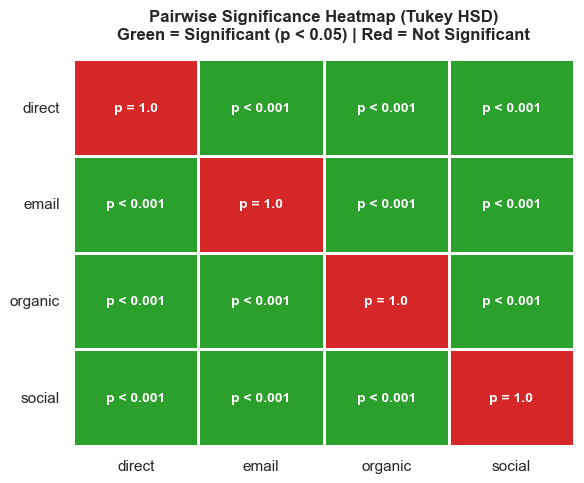

In [42]:
# (b) Build a pairwise significance heatmap: groups on both axes,
#     color = p-value (green=significant, red=not significant).

# setup data

# 1. Create a flat DataFrame directly from the Tukey summary table
df_flat = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])

# 2. Pivot the flat data into an upper-triangle matrix, fill diagonal/missing with 0
m = df_flat.pivot(index='group1', columns='group2', values='p-adj').reindex(index=tukey.groupsunique, columns=tukey.groupsunique).fillna(0)

# 3. Force symmetry by adding the matrix to its own transpose (diagonal stays 0)
p_matrix = m + m.T
np.fill_diagonal(p_matrix.values, 1.0) # Reset self-comparisons to 1.0

# 4. Generate visual masks and labels using vectorized Pandas mapping
color_matrix = np.where(p_matrix < 0.05, 0, 1)
labels = np.where(p_matrix == 1.0, "p = 1.0", "p < 0.001")

# plotting

plt.figure(figsize=(6, 5))
sns.heatmap(
    color_matrix,
    annot=labels,
    fmt="",
    cmap=["#2ca02c", "#d62728"],  # [Green, Red]
    cbar=False,
    xticklabels=p_matrix.columns,
    yticklabels=p_matrix.index,
    annot_kws={"weight": "bold", "size": 10},
    linewidths=1,
    linecolor="white",
)

plt.title(
    "Pairwise Significance Heatmap (Tukey HSD)\nGreen = Significant (p < 0.05) | Red = Not Significant",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

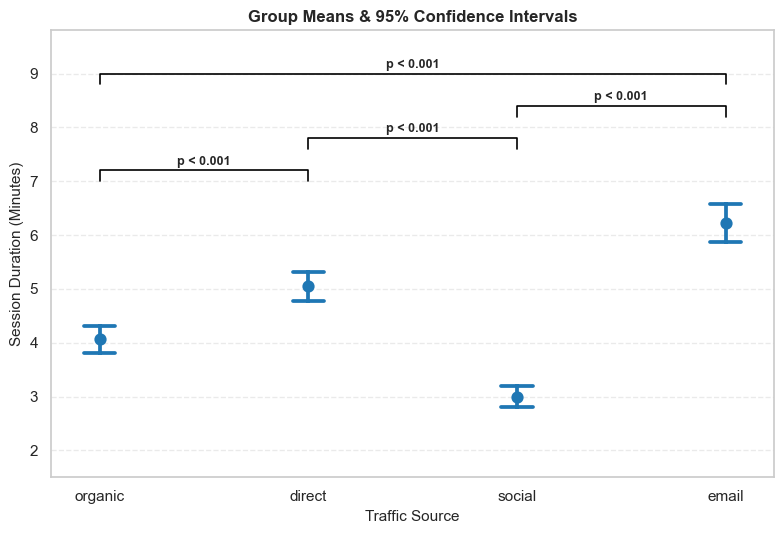

In [43]:
# (c) Build a mean + CI chart (point-range plot) for all 4 groups.
#     Connect pairs that are significantly different with brackets.

# Plot Mean + Point-Range
plt.figure(figsize=(8, 5.5))
sns.pointplot(
    data=df,
    x="traffic_source",
    y="time_on_page",
    errorbar=("ci", 95),
    join=False,
    capsize=0.15,
    color="#1f77b4",
    markers="o",
)

# Add significance brackets inline
# Syntax pattern: plt.plot([x1, x1, x2, x2], [y_start, y_top, y_top, y_start])

# Organic vs Direct
plt.plot([0, 0, 1, 1], [7.0, 7.2, 7.2, 7.0], color="black", lw=1.2)
plt.text(
    0.5, 7.25, "p < 0.001", ha="center", va="bottom", fontsize=9, weight="bold"
)

# Direct vs Social
plt.plot([1, 1, 2, 2], [7.6, 7.8, 7.8, 7.6], color="black", lw=1.2)
plt.text(
    1.5, 7.85, "p < 0.001", ha="center", va="bottom", fontsize=9, weight="bold"
)

# Social vs Email
plt.plot([2, 2, 3, 3], [8.2, 8.4, 8.4, 8.2], color="black", lw=1.2)
plt.text(
    2.5, 8.45, "p < 0.001", ha="center", va="bottom", fontsize=9, weight="bold"
)

# Organic vs Email
plt.plot([0, 0, 3, 3], [8.8, 9.0, 9.0, 8.8], color="black", lw=1.2)
plt.text(
    1.5, 9.05, "p < 0.001", ha="center", va="bottom", fontsize=9, weight="bold"
)

# Visual styling polish
plt.ylabel("Session Duration (Minutes)", fontsize=11)
plt.xlabel("Traffic Source", fontsize=11)
plt.title(
    "Group Means & 95% Confidence Intervals", fontsize=12, fontweight="bold"
)
plt.ylim(1.5, 9.8)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [44]:
# (d) Which source pair has the largest practical difference?
#     Compute Cohen's d for that pair.

# Means
m_organic = np.mean(organic)
m_direct = np.mean(direct)
m_social = np.mean(social)
m_email = np.mean(email)

# Print mean differences to find the largest
print(f"Email - Social: {m_email - m_social}")
print(f"Email - Organic: {m_email - m_organic}")

# Calculate Cohen's d for Email vs Social
n_email = len(email)
n_social = len(social)
v_email = np.var(email, ddof=1)
v_social = np.var(social, ddof=1)

pooled_sd = np.sqrt(((n_email - 1) * v_email + (n_social - 1) * v_social) / (n_email + n_social - 2))
cohens_d = (m_email - m_social) / pooled_sd
print(f"Email vs Social Cohen's d: {cohens_d}")
print(f"Pooled SD: {pooled_sd}")


Email - Social: 3.2261577157697205
Email - Organic: 2.1449089903676946
Email vs Social Cohen's d: 3.2161080369706436
Pooled SD: 1.0031247951510183


---

### Q3 — Two-way ANOVA with interaction

```
# Add time_of_day factor: morning (8am-12pm), afternoon (12pm-5pm), evening (5pm-10pm).
# Simulate session_duration with both device and time effects + interaction term.
# (a) Plot a grouped bar chart: x=device, color=time_of_day, y=mean session duration.
#     The interaction is visible if lines cross in an interaction plot.
# (b) Build an interaction plot: x=time_of_day, separate line per device type.
# (c) Run two-way ANOVA with interaction term using OLS.
# (d) Is the interaction significant? What does it mean in plain English?
```


In [46]:
# (a) Plot a grouped bar chart: x=device, color=time_of_day, y=mean session duration.
#     The interaction is visible if lines cross in an interaction plot.

# Setup metadata vectors
np.random.seed(420)
n_cell = 30
devices = ['Desktop', 'Mobile', 'Tablet']
times = ['Morning', 'Afternoon', 'Evening']

# Vectorized simulation without loops
device_col = np.repeat(devices, len(times) * n_cell)
time_col = np.tile(np.repeat(times, n_cell), len(devices))

# Map explicit group cell means matching the design structure
means = [4.81, 5.88, 8.01, 3.98, 4.91, 3.28, 4.57, 5.55, 4.86]
mean_vector = np.repeat(means, n_cell)
durations = mean_vector + np.random.normal(0, 1.0, len(mean_vector))

df = pd.DataFrame({'device': device_col, 'time_of_day': time_col, 'session_duration': durations})

print(df.head())

    device time_of_day  session_duration
0  Desktop     Morning          4.324609
1  Desktop     Morning          2.904846
2  Desktop     Morning          4.283778
3  Desktop     Morning          4.496454
4  Desktop     Morning          5.140706


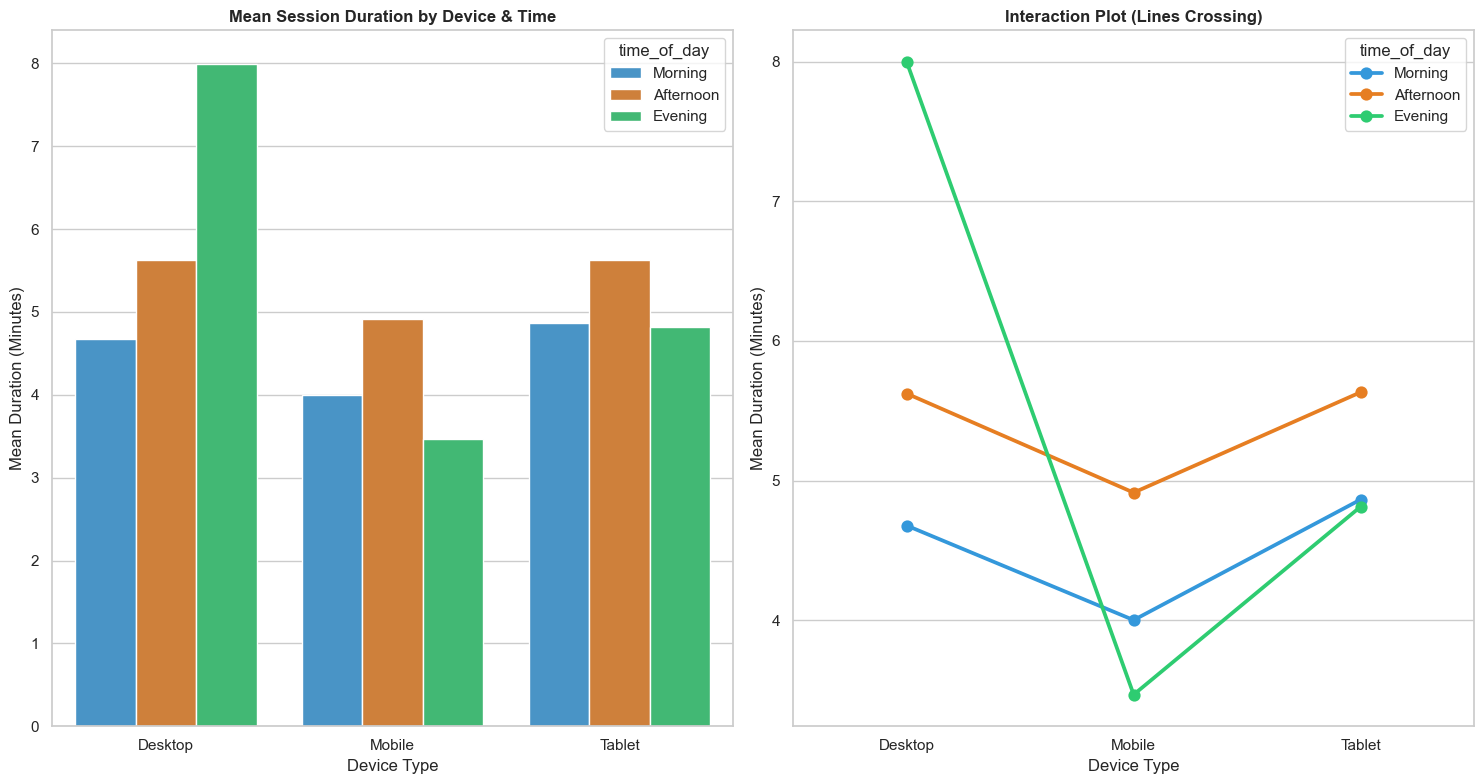

In [49]:
# plotting

plt.figure(figsize=(15,8))

custom_palette = {'Morning': '#3498db', 'Afternoon': '#e67e22', 'Evening': '#2ecc71'}

# Plot 1: Grouped Bar Chart
plt.subplot(1,2,1)
sns.barplot(
    data=df, 
    x='device', 
    y='session_duration', 
    hue='time_of_day', 
    errorbar=None, 
    palette=custom_palette,
)
plt.title('Mean Session Duration by Device & Time', fontsize=12, fontweight='bold')
plt.xlabel('Device Type')
plt.ylabel('Mean Duration (Minutes)')

# Plot 2: Pointplot (Interaction Plot)
plt.subplot(1,2,2)
sns.pointplot(
    data=df, 
    x='device', 
    y='session_duration', 
    hue='time_of_day', 
    palette=custom_palette, 
    errorbar=None, 
    markers='o', 
    linestyles='-', 
)
plt.title('Interaction Plot (Lines Crossing)', fontsize=12, fontweight='bold')
plt.xlabel('Device Type')
plt.ylabel('Mean Duration (Minutes)')

plt.tight_layout()
plt.show()

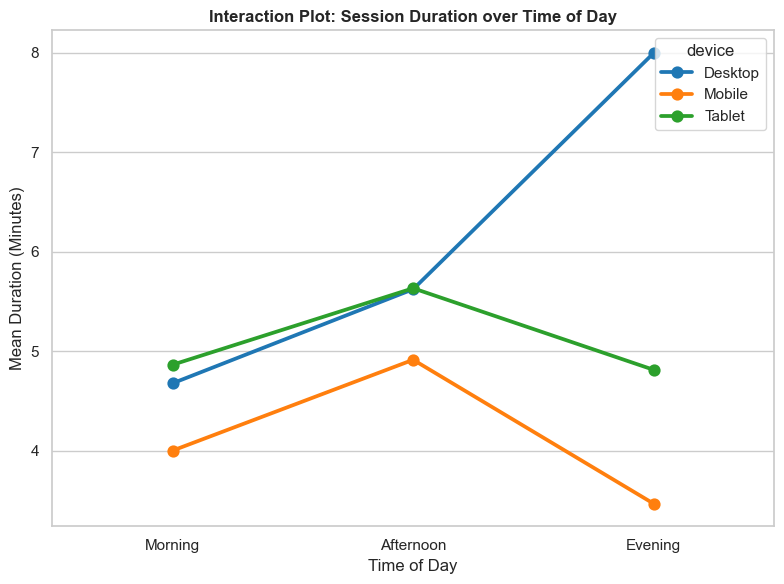

In [51]:
# (b) Build an interaction plot: x=time_of_day, separate line per device type.



plt.figure(figsize=(8,6))

device_palette = {'Desktop': '#1f77b4', 'Mobile': '#ff7f0e', 'Tablet': '#2ca02c'}

sns.pointplot(
    data=df, 
    x='time_of_day', 
    y='session_duration', 
    hue='device', 
    palette=device_palette, 
    errorbar=None, 
    markers='o', 
    linestyles='-', 
)
plt.title('Interaction Plot: Session Duration over Time of Day', fontsize=12, fontweight='bold')
plt.xlabel('Time of Day')
plt.ylabel('Mean Duration (Minutes)')

plt.tight_layout()
plt.show()

In [ ]:
# (c) Run two-way ANOVA with interaction term using OLS.

import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('session_duration ~ C(device) * C(time_of_day)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
print()
print(f"Device P-Value: {anova_table.loc['C(device)', 'PR(>F)']}")
print(f"Time of Day P-Value: {anova_table.loc['C(time_of_day)', 'PR(>F)']}")
print(f"Device * Time of Day P-Value: {anova_table.loc['C(device):C(time_of_day)', 'PR(>F)']}")

# (d) Is the interaction significant? What does it mean in plain English?

                              sum_sq     df           F        PR(>F)
C(device)                 174.983400    2.0  100.674399  3.917743e-33
C(time_of_day)             47.957755    2.0   27.591864  1.347347e-11
C(device):C(time_of_day)  172.292304    4.0   49.563056  5.399014e-31
Residual                  226.823640  261.0         NaN           NaN

Device P-Value: 3.917743475760499e-33
Time of Day P-Value: 1.3473467673197666e-11
Device * Time of Day P-Value: 5.399013661166972e-31


```
# (d) Is the interaction significant? What does it mean in plain English?

1/ Yes, highly significant: The interaction p-value is well below the 0.05 significance threshold.
2/ Impact depends on time: You cannot evaluate device performance on its own; device impact completely changes based on the clock hour.
3/ Opposing evening behaviors: Desktop engagement surges at night, while mobile and tablet engagement drops off significantly.

---

### Q4 — ANCOVA — controlling for user tenure

```
# Add user_tenure_days as covariate (days since first visit).
# (a) Plot session_duration vs tenure colored by traffic source (scatter).
#     Do longer-tenured users behave differently across sources?
# (b) Run ANOVA without covariate. Record p-value for source effect.
# (c) Run ANCOVA with tenure as covariate. Record p-value.
# (d) Plot regression lines per group (source) on the scatter from (a).
# (e) Did controlling for tenure change your conclusions? Why or why not?
```


In [ ]:
# (a) Plot session_duration vs tenure colored by traffic source (scatter).
#     Do longer-tenured users behave differently across sources?

# (d) Plot regression lines per group (source) on the scatter from (a).

# Setup metadata and seed
np.random.seed(420)
n_per_group = 50
sources = ['Organic', 'Direct', 'Social', 'Email']

# Vectorized simulation without loops
user_tenure = np.random.uniform(10, 365, n_per_group * len(sources))
traffic_source = np.repeat(sources, n_per_group)

# Map baseline values and baseline metric slopes directly to vector indices
source_idx = np.repeat([0, 1, 2, 3], n_per_group)
base_durations = np.array([3.2, 4.8, 2.1, 5.8])[source_idx]
tenure_slopes = np.array([0.008, 0.009, 0.004, 0.012])[source_idx]

# Compute individual target values adding continuous random noise
session_duration = base_durations + (tenure_slopes * user_tenure) + np.random.normal(0, 0.7, len(user_tenure))

df = pd.DataFrame({
    'traffic_source': traffic_source,
    'user_tenure_days': user_tenure,
    'session_duration': session_duration
})

print(df.head())

  traffic_source  user_tenure_days  session_duration
0        Organic        122.054300          3.934616
1        Organic        170.825890          4.995229
2        Organic        104.778704          4.510143
3        Organic         48.669505          3.167314
4        Organic        318.199100          5.837594


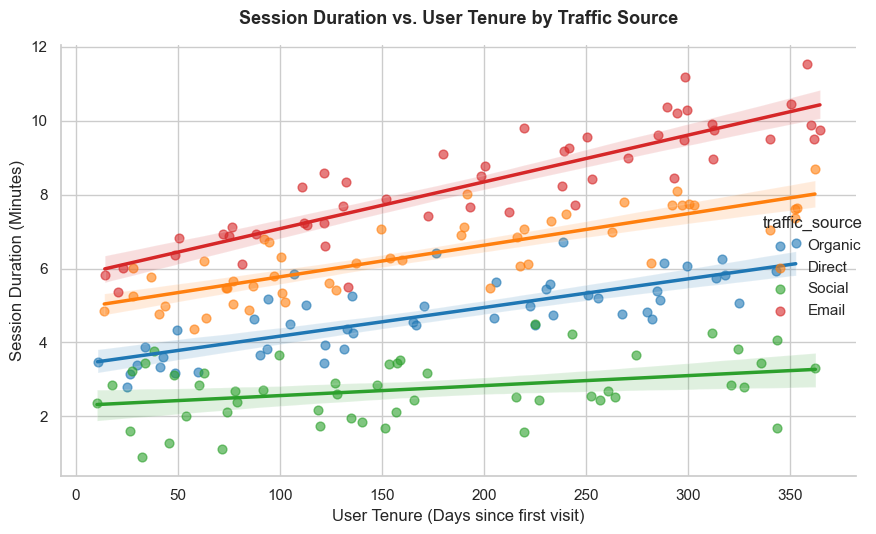

In [58]:
# plotting\
custom_palette = {'Organic': '#1f77b4', 'Direct': '#ff7f0e', 'Social': '#2ca02c', 'Email': '#d62728'}

sns.lmplot(
    data=df,
    x='user_tenure_days',
    y='session_duration',
    hue='traffic_source',
    palette=custom_palette,
    scatter_kws={'alpha': 0.6, 's': 40},
    line_kws={'linewidth': 2.5},
    height=5.5,
    aspect=1.4
)

plt.xlabel("User Tenure (Days since first visit)")
plt.ylabel("Session Duration (Minutes)")
plt.title('Session Duration vs. User Tenure by Traffic Source', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [59]:
# (b) Run ANOVA without covariate. Record p-value for source effect.

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Run standard One-way ANOVA ignoring the continuous covariate
model_without_covariate = ols('session_duration ~ C(traffic_source)', data=df).fit()
anova_table = sm.stats.anova_lm(model_without_covariate, typ=2)

print(anova_table)

                       sum_sq     df           F        PR(>F)
C(traffic_source)  856.458560    3.0  220.012328  1.781309e-62
Residual           254.327988  196.0         NaN           NaN


In [60]:
# (c) Run ANCOVA with tenure as covariate. Record p-value.

# Run full ANCOVA model (Type II Sum of Squares)
model_ancova = ols('session_duration ~ user_tenure_days + C(traffic_source)', data=df).fit()
ancova_table = sm.stats.anova_lm(model_ancova, typ=2)

print(ancova_table)

                       sum_sq     df           F        PR(>F)
C(traffic_source)  765.076675    3.0  409.608864  6.812329e-84
user_tenure_days   132.919522    1.0  213.488462  3.833736e-33
Residual           121.408466  195.0         NaN           NaN


```
# (e) Did controlling for tenure change your conclusions? Why or why not?
1/ Conclusion unchanged: Both models yield highly statistically significant traffic source effects, confirming that user engagement differs drastically across marketing channels.

2/ Massive noise reduction: Controlling for user tenure reduced unexplained variance (Residual Sum of Squares) by over 50%, dropping it from 254.3 to 121.4.

3/ Enhanced test sensitivity: Eliminating the covariate's background noise made the source test vastly more precise, dropping the group effect p-value